<a href="https://colab.research.google.com/github/ariyanabonab/diffusion-ic/blob/training-practice/notebooks/01-Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installing JaxPM
#!pip install --quiet jaxpm
#!pip install --quiet --upgrade jax
!pip uninstall jaxlib
!pip uninstall jaxpm
# ... rest of your installations
# CPU-only for a clean first run alongside JAX.
!pip -q install torch score_models h5py tqdm
!pip install score_models
#import jax.numpy as jnp
import os
os.environ["JAX_PLATFORMS"] = "cpu"

Found existing installation: jaxlib 0.5.3
Uninstalling jaxlib-0.5.3:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/jaxlib-0.5.3.dist-info/*
    /usr/local/lib/python3.12/dist-packages/jaxlib/*
Proceed (Y/n)? y
  Successfully uninstalled jaxlib-0.5.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 5.1 MB/s eta 0:00:00


In [2]:
pip install jax==0.7.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 MB 10.2 MB/s eta 0:00:00
  Attempting uninstall: jax
    Found existing installation: jax 0.5.3
    Uninstalling jax-0.5.3:
      Successfully uninstalled jax-0.5.3


In [3]:
pip install jaxpm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 25.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.4/170.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.1 MB/s eta 0:00:00
  Created wheel for jax_cosmo: filename=jax_cosmo-0.1.0-py3-none-any.whl size=35704 sha256=f4d119a023787cbe7b5ded6a2129ce677cbb71ffaddccda7fcba8ce62a53c191
  Stored in directory: /root/.cache/pip/wheels/aa/64/a3/e17d1388542422c2aff33356d9d3beb9afbd418524a85e5647
Successfully built jax_cosmo


In [4]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc

from jax.experimental.ode import odeint
from jaxpm.painting import cic_paint
# from jax.ffi import cic_paint
from jaxpm.pm import linear_field, lpt, make_ode_fn

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.3 is installed, but it is not compatible with the installed jaxlib version 0.7.0, so it will not be used.
  warnings.warn(


In [5]:
import numpy as np

mesh_shape = [32, 32, 32]
box_size = [32., 32., 32.]
snapshots = jnp.array([0.1, 0.5, 1.0])


#@jax.jit
def run_simulation(omega_c, sigma8):
    # Create a small function to generate the matter power sp ectrum
    k = jnp.logspace(-4, 1, 128)
    pk = jc.power.linear_matter_power(jc.Planck15(Omega_c=omega_c, sigma8=sigma8), k)
    pk_fn = lambda x: jnp.interp(x.reshape([-1]), k, pk).reshape(x.shape)
    cosmo = jc.Planck15(Omega_c=omega_c, sigma8=sigma8)
    particles = jnp.stack(jnp.meshgrid(*[jnp.arange(s) for s in mesh_shape]),axis=-1).reshape([-1,3])

    for i in range(101):
      seed = jax.random.PRNGKey(i)
      initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=seed)
      dx, p, f = lpt(cosmo, initial_conditions, particles, a=0.1)
      lpt_particles = particles + dx # Assign lpt_particles here
      res = odeint(make_ode_fn(mesh_shape), [lpt_particles, p], snapshots, cosmo, rtol=1e-8, atol=1e-8)
      ode_particles = res[0] # Assign ode_particles here
      ic = initial_conditions[None,...]
      np.save(f"ic_{i}.npy", ic)
      print(f"Saved ic_{i}.npy")
      fields = {"Initial Conditions" : ic , "LPT Field" : jnp.log10(cic_paint(jnp.zeros(mesh_shape) ,lpt_particles) + 1)}
      final_density = jnp.log10(cic_paint(jnp.zeros(mesh_shape) , ode_particles[-1])+1) # Use the last timestep's particles
      fd = final_density[None,...] # numpy trick that allows for 1,N,N,N shape
      np.save(f"fd_{i}.npy", fd)
      print(f"Saved fd_{i}.npy")

ic , lpt_particles , ode_particles = run_simulation(0.25, 0.8) #
#ic , ode_particles = run_simulation(0.25, 0.8)

/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Saved ic_0.npy
Saved fd_0.npy
Saved ic_1.npy
Saved fd_1.npy
Saved ic_2.npy
Saved fd_2.npy
Saved ic_3.npy
Saved fd_3.npy
Saved ic_4.npy
Saved fd_4.npy
Saved ic_5.npy
Saved fd_5.npy
Saved ic_6.npy
Saved fd_6.npy
Saved ic_7.npy
Saved fd_7.npy
Saved ic_8.npy
Saved fd_8.npy
Saved ic_9.npy
Saved fd_9.npy
Saved ic_10.npy
Saved fd_10.npy
Saved ic_11.npy
Saved fd_11.npy
Saved ic_12.npy
Saved fd_12.npy
Saved ic_13.npy
Saved fd_13.npy
Saved ic_14.npy
Saved fd_14.npy
Saved ic_15.npy
Saved fd_15.npy
Saved ic_16.npy
Saved fd_16.npy
Saved ic_17.npy
Saved fd_17.npy
Saved ic_18.npy
Saved fd_18.npy
Saved ic_19.npy
Saved fd_19.npy
Saved ic_20.npy
Saved fd_20.npy
Saved ic_21.npy
Saved fd_21.npy
Saved ic_22.npy
Saved fd_22.npy
Saved ic_23.npy
Saved fd_23.npy
Saved ic_24.npy
Saved fd_24.npy
Saved ic_25.npy
Saved fd_25.npy
Saved ic_26.npy
Saved fd_26.npy
Saved ic_27.npy
Saved fd_27.npy
Saved ic_28.npy
Saved fd_28.npy
Saved ic_29.npy
Saved fd_29.npy
Saved ic_30.npy
Saved fd_30.npy
Saved ic_31.npy
Saved fd_31.

TypeError: cannot unpack non-iterable NoneType object

In [24]:
yimport numpy as np
from jaxpm.plotting import plot_fields_single_projection

mesh_shape = [32, 32, 32]
box_size = [32., 32., 32.]
snapshots = jnp.array([0.1, 0.5, 1.0])

@jax.jit
def run_simulation(omega_c, sigma8):
    # Create a small function to generate the matter power spectrum
    k = jnp.logspace(-4, 1, 128)
    pk = jc.power.linear_matter_power(jc.Planck15(Omega_c=omega_c, sigma8=sigma8), k)
    pk_fn = lambda x: jnp.interp(x.reshape([-1]), k, pk).reshape(x.shape)

    for i in range(101):
      seed = jax.random.PRNGKey(i)
      initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=seed)
      ic_np = np.array(initial_conditions[None, ...])
      np.save(f"ic_{i}.npy", ic_np)
      print(f"Saved ic_{i}.npy")
# for i in range[_]
# initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(_))

    # Create initial conditions and particles
    #initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(2)) # change this 0 or 1 to another number each time i run it
    #particles = jnp.stack(jnp.meshgrid(*[jnp.arange(s) for s in mesh_shape]),axis=-1).reshape([-1,3])

    # Initial displacement
    cosmo = jc.Planck15(Omega_c=omega_c, sigma8=sigma8)
    dx, p, f = lpt(cosmo, initial_conditions, particles, a=0.1)

    # Evolve the simulation forward
    res = odeint(make_ode_fn(mesh_shape), [particles + dx, p], snapshots, cosmo, rtol=1e-8, atol=1e-8)

    # Return the simulation volume at requested timesteps
    return initial_conditions ,  particles + dx , res[0]

#initial_conditions[None,...]
#ic = initial_conditions[None,...]
#ic.shape
#np.save('ic_' + '[i]' + '.npy')


# Create a NumPy array
#arr = np.array([1, 2, 3, 4, 5])

# Save the array to a file named 'my_array.npy'
#np.save('my_array.npy', arr)

#print(ic)

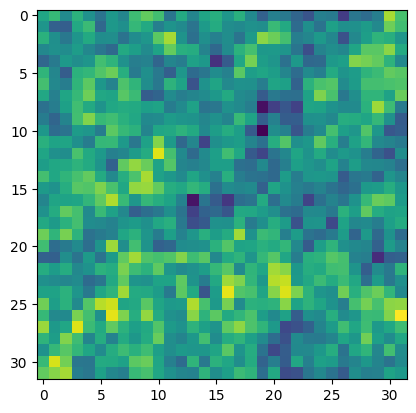

In [18]:
import matplotlib.pyplot as plt
x = np.load('ic_2.npy')
x2 = np.load('fd_2.npy')
plt.imshow(x2[0,0])
plt.imshow(x[0,0])

#x2 = np.load('ic_0.npy')
#plt.imshow(x2[0,0])



In [ ]:
# in this cell save each ic and fd as ic_0.npy
# using np.save

In [13]:
final_density = jnp.log10(cic_paint(jnp.zeros(mesh_shape) , field)+1)
print(final_density)

NameError: name 'field' is not defined

In [31]:
#fd = final_density[None,...] # numpy trick that allows for 1,N,N,N shape
#fd.shape

initial_conditions[None,...]
ic = initial_conditions[None,...]
ic.shape

# save np.save for ic and fd to put into getitem

# after this line can save fd and ic to disk save as 0.ic.npy, 0.fd.npy, each time i save

# make a for loop to then save each, or i can manually change it from 0 to 100 each time
# np.save for both

(1, 32, 32, 32)

In [32]:
# initial_conditions vs ic , ic has 4 brackets vs initial_conditions has 3 brackets to account for shape 1, N, N, N
# reload each with getiem to load each in disk
# how to change each ic so its different each time


In [31]:
import torch
from torch.utils.data import TensorDataset
from score_models import ScoreModel, EnergyModel, MLP, NCSNpp
import shutil, os
import numpy as np

# can tweak dimensions, nf, ch_mult, sigma_min, sigma_max, epochs, batch_size, learning_rate, and steps

dimensions = 3
nf = 128
sigma_min = 1e-3
sigma_max = 1e2
epochs = 1
batch_size = 1
learning_rate = 1e-4
steps = 100

class Dataset(torch.utils.data.Dataset):
    def __init__(self):
      pass

    def __len__(initial_conditions):
        return 100 #len(os.listdir('.'))//2  # fix this with : len(os.listdir('.'))//2

    def __getitem__(self, i):
      final_d = np.load(f'ic_{i}.npy')
      initial_c = np.load(f'fd_{i}.npy')
      return final_d, initial_c
dataset = Dataset()
#dataset[0]
   # i know i want to put my IC, FD input here into getitem and index = final_density
      # go to file location, go to wherever you saved on disk to then load here
      # return ic and fd both which i loaded from file
      # to check if works, use dataset = Dataset()
      # then try print(dataset[i]) and this should print ic and fd
      # if this does not give error then it is done correctly

In [ ]:
print("Loading:", filename)
data = np.load(filename)

In [20]:
initial_conditions , lpt_particles , ode_particles = run_simulation(0.25, 0.8)

/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Saved ic_0.npy
Saved fd_0.npy


KeyboardInterrupt: 

In [32]:
from score_models import ScoreModel, EnergyModel, NCSNpp, MLP, DDPM
from torch.utils.data import Dataset # Import Dataset
import torch # Import torch

# B is the batch size
# C is the input channels
# dimensions are the spatial dimensions (e.g. [28, 28] for MNIST)

# Create a ScoreModel instance with Yang Song's NCSN++ architecture and the VESDE
#net = NCSNpp(channels=C, dimensions=len(dimensions), nf=128, ch_mult=[2, 2, 2, 2])
#model = ScoreModel(model=net, sigma_min=1e-3, sigma_max=40, device="cpu")
# ... or the VPSDE
B = 3
C = 1
dimensions = [32, 32]

# NN Architectures support a Unet with 1D convolutions for time series input data
net = NCSNpp(channels=C, nf=128, ch_mult=[2, 2, 2, 2], dimensions=3, condition = ('input',), condition_input_channels = 1,)
# ... or 3D convolutions for videos/voxels
##net = NCSNpp(channels=1, nf=128, ch_mult=[2, 2, 2, 2], attention=False, dimensions=3)
# You can also use a simpler MLP architecture (dimensions=0)
#net = MLP(dimensions=C, layers=4, units=100)
# ... or Jonathan Ho's DDPM architecture
#net = DDPM(channels=1, nf=128, ch_mult=[2, 2, 2, 2], conditioning = ('input',))
model = ScoreModel(model=net, beta_min=1e-3, beta_max=40, device="cpu")

# Define B, C, and dimensions (using values from the test_training_conditioned_input_ncsnpp function as an example)
# Assuming 2D data based on the commented out NCSNpp example

# Train the score model, and save its weight in checkpoints_directory
model.fit(dataset, epochs=100, batch_size=B, learning_rate=1e-4, checkpoints_directory='.')

# Generate samples from the trained model (steps is the number of Euler-Maruyama steps)
samples = model.sample(shape=[B, C, *dimensions], steps=100) # Added C to shape

# Compute the score for a given input
# Need to define 't' and 'x' before calling model.score(t, x)
# score = model.score(t, x)

# Initialise the score model and its neural network from a path to a checkpoint directory
# Need to define 'checkpoints_directory' before calling ScoreModel(checkpoints_directory=checkpoints_directory)
# model = ScoreModel(checkpoints_directory=checkpoints_directory)

# TO DO: run 100 sims to output IC & FD in shape (1,N,N,N)

# try working this on local machine (jupyter notebook)

Using the Variance Preserving SDE


  0%|          | 0/100 [00:00<?, ?it/s]


EOFError: No data left in file

In [30]:
from jaxpm.plotting import plot_fields_single_projection

fields = {"Initial Conditions" : initial_conditions , "LPT Field" : jnp.log10(cic_paint(jnp.zeros(mesh_shape) ,lpt_particles) + 1)}
for i , field in enumerate(ode_particles[1:]):
    fields[f"field_{i}"] = jnp.log10(cic_paint(jnp.zeros(mesh_shape) , field)+1)
plot_fields_single_projection(fields)

NameError: name 'initial_conditions' is not defined